# Import Required Libraries and Create Clean Datasets

## Import Required Libraries

In [320]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import urllib.request
from bs4 import BeautifulSoup
import sqlite3
import sys
!{sys.executable} -m pip install "kagglehub[pandas-datasets]"
import kagglehub
# print("kagglehub works!")
from kagglehub import KaggleDatasetAdapter
import statsmodels.api as sm
from scipy.stats import ttest_ind

## Webscrape the Hosts for Each Year

### Fetch and Locate Hosts Data

In [321]:
# Fetch HTML from Wikipedia page
hosts_url = "https://en.wikipedia.org/wiki/FIFA_World_Cup"

# Create request with custom User Agent to avoid having the request blocked
req = urllib.request.Request(hosts_url, headers={"User-Agent" : "Magic Browser"})

# Retrieve page content
con = urllib.request.urlopen(req)

# Parse the HTML using BeautifulSoup
soup = BeautifulSoup(con.read(), "html.parser")

# Find all tables with the class "wikitable"
wiki_tables = soup.find_all("table", class_=lambda x: x and "wikitable" in x)

# Print number of tables found (commented out after observing)
# print(len(wiki_tables))

# Find table with host countries and year
host_table = None
for table in wiki_tables:
    table_header = table.find_all("th") # Get all header cells
    table_header_txt = " ".join([h.text.strip().lower()
                                 for h in table_header]) # Make a list of lowercase header cells so key words can be searched for
    # Print all header strings so we can choose the most relevant table (commented out after observing)
    # print(table_header_txt)
    if "year" in table_header_txt and "host" in table_header_txt:
        host_table = table # Select the table that has "year" and "host" as headers
        break

# Print to confirm we have the right wikitable (commented out after observing)        
# print(host_table)


### Extract Hosts Data to a DataFrame and Export Raw Data to CSV

In [322]:
# Get every row from the table
rows = host_table.find_all("tr")

data = []

# Skip the first two rows (column names) and extract the rest
for row in rows[2:]:
    cols = [c.text.strip() for c 
            in row.find_all(["td", "th"])] # Extract <td> and <th> without spaces
    data.append(cols)

# Convert to DataFrame
host_df = pd.DataFrame(data, columns = ["Edition", "Year", "Host", "First Place", "Score", 
                                   "Runner-up", "Third Place", "Score2", "Fourth Place", "Nr. of Teams"])

# Print out to check DataFrame (commented out after observing)
# print(host_df)

# Save raw DataFrame as a CSV file
host_df.to_csv("hosts_and_years_raw.csv")


## Cleaning Hosts Data

### Check Data Type for Each Column

In [323]:
# Check data type for each column  (commented out after observing)
# host_df.info()

### Check for Missing Data in the Dataset

In [324]:
# Check for missing data in the dataset  (commented out after observing)
data_missing = host_df.isnull()
# data_missing

In [325]:
# Find missing data count per column (commented out after observing)
# host_df.isnull().sum()

### Drop Rows with Missing Data

##### In 1942 and 1946 no World Cup took place due to WWII
##### The 2026, 2030 and 2034 World Cups haven't taken place yet
##### There is no data for these rows so they should be dropped

#### Clean Missing Score Columns Using SQL

In [326]:
# Create a copy of the original DataFrame to prevent changing raw data
host_df1 = host_df.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
host_df1.to_sql("host_df1", conn, if_exists = "replace", index=False)

# Replace "None", "NaN" and NULL values with an empty string
host_df1 = conn.execute("""
    UPDATE host_df1
    SET Score = ""
    WHERE Score IS NULL OR Score = 'None' OR Score = 'NaN'
""")
conn.commit()

# Print the Score and Year column to check this worked
score_updated = pd.read_sql("""
    SELECT Year, Score
    FROM host_df1
""", conn)

# Print to check this worked (commented out after observing)
# print(score_updated.to_string(index = False))


#### Check we are Dropping the Correct Rows Using SQL

In [327]:
# Check we are dropping the correct rows
check_empty = pd.read_sql("""
    SELECT *
    FROM host_df1
    WHERE Score = ""
""", conn)

# Print to check (commented out after observing)
# print(check_empty.to_string(index = False))

#### Delete the Rows Using SQL

In [328]:
# Dropping the missing data
host_df1 = conn.execute("""
    DELETE FROM host_df1
    WHERE Score = ""
""")
conn.commit()

# Check this worked
rows_not_deleted = pd.read_sql("""
    SELECT *
    FROM host_df1
""", conn)

# Print to check (commented out after observing)
# print(rows_not_deleted.to_string(index = False))

#### Extract Relevant Columns Only Using SQL

In [329]:
# Extract "Year" and "Host" from the hosts_table
host_df1 = pd.read_sql("""
    SELECT Year, Host
    FROM host_df1
""", conn)

# Print the filtered DataFrame to check this worked (commented out after observing)
# print(host_df1.to_string(index=False))

## Download Elo Ratings Dataset into Pandas

##### Please refer to the README file regarding this code
##### The only complete source of Elo Ratings is a JavaScript webpage so I was not able to webscrape as I am not familiar enough with Selenium
##### Instead, this Dataset is downloaded from Kagglehub into Pandas

### Download and Locally Save the Elo Dataset

In [330]:
# Specify the file within the kagglehub dataset
target_file_path = "eloratings.csv"

# Download the specified dataset directly into a Pandas DataFrame
elo_ranking_raw = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "saifalnimri/international-football-elo-ratings",
  target_file_path,
)

# Print to check this has worked properly (commented out after observing)
# print(elo_ranking_raw)

# Save as CSV file
elo_ranking_raw.to_csv("elo_ranking_raw.csv")

/var/folders/kd/p53w9pwd7rv29w5h_tss9l580000gn/T/ipykernel_21837/2582643254.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  elo_ranking_raw = kagglehub.load_dataset(


## Cleaning Elo Data

### Check Data Type for Each Column

In [331]:
# Check data type for each column  (commented out after observing)
# elo_ranking_raw.info()

### Check for Missing Data in the Dataset

In [332]:
# Check for missing data in the dataset  (commented out after observing)
data_missing = elo_ranking_raw.isnull()
# data_missing

In [333]:
# Find missing data count per column (commented out after observing)
# elo_ranking_raw.isnull().sum()

### Drop rows where rating is missing using SQL

##### Please refer to the README file for the reasoning of this

#### Clean missing rating column using SQL

In [334]:
# Create a copy of the original DataFrame to prevent changing raw data
elo_ranking1 = elo_ranking_raw.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
elo_ranking1.to_sql("elo_ranking1", conn, if_exists = "replace", index=False)

# Replace "None", "NaN" and NULL values with an empty string
elo_ranking1 = conn.execute("""
    UPDATE elo_ranking1
    SET rating = ""
    WHERE rating IS NULL OR rating = 'None' OR rating = 'NaN'
""")
conn.commit()

# Print the rating, date and team columns to check this worked
rating_updated = pd.read_sql("""
    SELECT rating, date, team
    FROM elo_ranking1
""", conn)

# Print to check this worked (commented out after observing)
# print(rating_updated.to_string(index = False))


#### Check we are Dropping the Correct Rows Using SQL

In [335]:
# Check we are dropping the correct rows
check_empty = pd.read_sql("""
    SELECT *
    FROM elo_ranking1
    WHERE rating = ""
""", conn)

# Print to check (commented out after observing)
#print(check_empty.to_string(index = False))

# Note: all empty ratings are Moldova


#### Delete the Rows Using SQL

In [336]:
# Dropping the missing data
elo_ranking1 = conn.execute("""
    DELETE FROM elo_ranking1
    WHERE rating = ""
""")
conn.commit()

# Check this worked
rows_not_deleted = pd.read_sql("""
    SELECT *
    FROM elo_ranking1
""", conn)

# Print to check (commented out after observing)
# print(rows_not_deleted.to_string(index = False))

#### Check Rows were Deleted Properly

In [337]:
# Convert SQLite elo_ranking1 to pandas DataFrame
elo_ranking1 = pd.read_sql("""
    SELECT * 
    FROM elo_ranking1
""", conn)

# Return how many null in each column (commented out after observing)
# elo_ranking1.isnull().sum()

### Clean date column to be year only in elo_ranking

In [338]:
# Make copy of table to avoid changing raw data
elo_ranking2 = elo_ranking1.copy()

# Clean to year only (from mixed formatting)
elo_ranking2["date"] = pd.to_datetime(
    elo_ranking2["date"], format = "mixed"
).dt.year

# Check this worked for both date formats (commented out after observing)
# print(elo_ranking2)

### Check for duplicate years in each country for elo_ranking

#### Check how many duplicates are in the DataFrame

In [339]:
# Check how many duplicates are in the DataFrame
duplicates_count = elo_ranking2.duplicated(subset = ["date", "team"]).sum()

# Print to check (commented out after observing)
# print(duplicates_count)

### Clean to get rid of duplicates in elo_ranking

#### Create an average for the ratings column where entries have the same year and team

In [340]:
# Group together entries where date (year) and team are the same, and make the rating the average of these previous entries
elo_ranking3 = elo_ranking2.groupby(["date", "team"], as_index = False)["rating"].mean()

# Print to check (commented out after observing)
# print(elo_ranking3)

#### Check this worked by re-checking for duplicates

In [341]:
# Check how many duplicates are in the DataFrame
duplicates_count = elo_ranking3.duplicated(subset = ["date", "team"]).sum()

# Print to check (commented out after observing)
# print(duplicates_count)
# elo_ranking3

## Webscrape the Names of All Participant Countries

### Fetch and Locate Hosts Data

In [342]:
# Fetch HTML from Wikipedia page
participants_url = "https://en.wikipedia.org/wiki/National_team_appearances_in_the_FIFA_World_Cup"

# Create request with custom User Agent to avoid having the request blocked
req = urllib.request.Request(participants_url, headers={'User-Agent' : "Magic Browser"}) 

# Retrieve page content
con = urllib.request.urlopen(req)

# Parse the HTML using BeautifulSoup
soup = BeautifulSoup(con.read(), "html.parser")

# Find all tables with the class "wikitable"
wiki_table_participants = soup.find_all("table", class_=lambda x: x and "wikitable" in x)

# Print number of tables found (commented out after observing)
#print(len(wiki_table_participants))

# Find table with host countries and year
participants_table = None
for table in wiki_table_participants:
    table_header = table.find_all("th") # Get all header cells
    table_header_txt = " ".join([h.text.strip().lower()
                                 for h in table_header]) # Make a list of lowercase header cells so key words can be searched for
    # Print all header strings so we can choose the most relevant table (commented out after observing)
    # print(table_header_txt)
    if "team" in table_header_txt and "appearances" in table_header_txt:
        participants_table = table # Select the table that has "team" and "appearances" as headers
        break

# Print to confirm we have the right wikitable (commented out after observing)        
# print(participants_table)

### Extract Hosts Data to a DataFrame and Export Raw Data to CSV

In [343]:
# Get every row from the table
rows = participants_table.find_all('tr')

data = []

# Skip the first row (column names) and extract the rest
for row in rows[1:]:
    cols = [c.text.strip() for c 
            in row.find_all(['td', 'th'])] # Extract <td> and <th> without spaces
    data.append(cols)

# Convert to DataFrame
participants = pd.DataFrame(data, columns = ["Team", "Appearances", "Record Streak", "Active Streak", "Debut", 
                                   "Most Recent Qualification", "Best Result"])

# Print out to check DataFrame (commented out after observing)
# print(participants)

# Save raw DataFrame as a CSV file
participants.to_csv("participants_raw.csv")


## Cleaning Participant Country DataFrame

### Delete the countries that have not yet debuted (debut in 2026)

In [344]:
# Create a copy of the original DataFrame to prevent changing raw data
participants1 = participants.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
participants1.to_sql("participants1", conn, if_exists="replace", index=False)

# Dropping the missing data
participants1 = conn.execute("""
    DELETE FROM participants1
    WHERE Debut = 2026
""")
conn.commit()

# Check this worked
rows_deleted = pd.read_sql("""
    SELECT *
    FROM participants1
""", conn)

# Print to check (commented out after observing)
# print(rows_deleted.to_string(index=False))


## Webscrape Stats Per Country Per Year

In [345]:
# Extract World Cup  years from Hosts DataFrame
years = host_df1["Year"].tolist()

# Check this worked (commented out after observing)
# print(years)

""" Remove 1978, 1990 and 2002 from the 'years' variable since they do not display the same result when ran 
since they have different column names """
years.remove("1978")
years.remove("1990")
years.remove("2002")

# Check this worked (commented out after observing)
# print(years)

all_rows = []

# Webscrape final rankings by looping through each World Cup year's wikipedia page
for year in years:

    # Fetch HTML from each year's Wikipedia page
    points_url = f"https://en.wikipedia.org/wiki/{year}_FIFA_World_Cup"

    # Print to check the URLs work (commented out after observing)
    # print("URL:",points_url)

    # Create request with custom User Agent to avoid having the request blocked
    req = urllib.request.Request(points_url, headers={'User-Agent' : "Magic Browser"})

    # Retrieve page content
    con = urllib.request.urlopen(req)

    # Parse the HTML using BeautifulSoup
    soup = BeautifulSoup(con.read(), "html.parser")

    # Find all tables with the class "wikitable" on each page individually
    wiki_table_points = soup.find_all("table", class_="wikitable")

    # Identify the "final ranking" table on each page individually
    points_table = None
    for table in wiki_table_points:

        if points_table is not None:
            break
        header = table.find("tr")
        if header:
            first_th = header.find("th")

            # Identify the "final ranking" table by detecting < abbr > title = "final ranking" 
            if first_th:
                abbr = first_th.find("abbr")
                if abbr and "final ranking" == abbr.get("title", "").lower():
                    points_table = table
     
            if points_table is None:
            # Extract rows from the table

                """ If this does not return a table, identify the "final ranking" table based on length 
                (longer than knockout round tables which are all less than 8 historically) and header text """
                if points_table is None and len(table.find_all("tr")) > 8:
                    last_th = header.find_all("th")[-1]
                    if last_th:
                        text = last_th.text.strip()
                    
                    # Print header text to check what is happening (commented out after observing)
                        # print ("TEXT:", text)

                    # If header equals "Result", treat this as the "final ranking" table
                        if text and "Result" == text:
                            points_table = table

    if points_table is not None:
        # Extract rows from the table 
        rows = points_table.find_all("tr")
    
        for row in rows[1:]:  # Skip header row
            cols = row.find_all(["td", "th"]) # Some years have 13 columns - drop column 13
            
            # Print number of columns to check what is happening (commented out after observing)
            # print("COLLEN: ", len(cols))

            # Clean text from each cell
            cols = [col.get_text(strip=True) for col in cols]
    
            if cols:
                all_rows.append([year] + cols[:11])
    
        # Create DataFrame
        total_points_table_raw = pd.DataFrame(all_rows, columns = ["Year", "Ranking", "Team", "Group", "Matches Played", "Matches Won", 
                                           "Matches Drawn", "Matches Lost", "Goals For", "Goals Against",
                                           "Goal Difference", "Points"])
    
        #print(total_points_table)

    # else:
        # print(f"TABLE NOT FOUND{year}")  # Returns if any years haven't worked so code can be edited (commented out after observing)                      

# Print to check this has worked (commented out after observing)
# print(total_points_table_raw.to_string(index=False))

# Save raw DataFrame as a CSV file
total_points_table_raw.to_csv("total_points_table_raw.csv")


In [346]:
# Extract World Cup  years from Hosts DataFrame
years = ["1978", "1990", "2002"]

# Check this worked (commented out after observing)
# print(years)

all_rows = []

# Webscrape final rankings by looping through each World Cup year's wikipedia page
for year in years:

    # Fetch HTML from each year's Wikipedia page
    points_url = f"https://en.wikipedia.org/wiki/{year}_FIFA_World_Cup"

    # Print to check the URLs work (commented out after observing)
    # print("URL:",points_url)

    # Create request with custom User Agent to avoid having the request blocked
    req = urllib.request.Request(points_url, headers={'User-Agent' : "Magic Browser"})

    # Retrieve page content
    con = urllib.request.urlopen(req)

    # Parse the HTML using BeautifulSoup
    soup = BeautifulSoup(con.read(), "html.parser")

    # Find all tables with the class "wikitable" on each page individually
    wiki_table_points = soup.find_all("table", class_="wikitable")

    # Identify the "final ranking" table on each page individually
    points_table = None
    for table in wiki_table_points:

        if points_table is not None:
            break
        header = table.find("tr")
        if header:
            first_th = header.find("th")

            # Identify the "final ranking" table by detecting < abbr > title = "final ranking" 
            if first_th:
                abbr = first_th.find("abbr")
                if abbr and "final ranking" == abbr.get("title", "").lower():
                    points_table = table
     
            if points_table is None:
            # Extract rows from the table

                """ If this does not return a table, identify the "final ranking" table based on length 
                (longer than knockout round tables which are all less than 8 historically) and header text """
                if points_table is None and len(table.find_all("tr")) > 8:
                    last_th = header.find_all("th")[-1]
                    if last_th:
                        text = last_th.text.strip()
                    
                    # Print header text to check what is happening (commented out after observing)
                        # print ("TEXT:", text)

                    # If header equals "Result", treat this as the "final ranking" table
                        if text and "Result" == text:
                            points_table = table

    if points_table is not None:
        # Extract rows from the table 
        rows = points_table.find_all("tr")
    
        for row in rows[1:]:  # Skip header row
            cols = row.find_all(["td", "th"]) # Some years have 13 columns - drop column 13
            
            # Print number of columns to check what is happening (commented out after observing)
            # print("COLLEN: ", len(cols))

            # Clean text from each cell
            cols = [col.get_text(strip=True) for col in cols]
    
            if cols:
                all_rows.append([year] + cols[:12])
    
        # Create DataFrame
        total_points_table_2_raw = pd.DataFrame(all_rows, columns = ["Year", "Ranking", "Group", "Team", "Matches Played", "Matches Won", 
                                           "Matches Drawn", "Matches Lost", "Goals For", "Goals Against",
                                           "Goal Difference", "Points", "Result"])
    

    # else:
        # print(f"TABLE NOT FOUND{year}")  # Returns if any years haven't worked so code can be edited (commented out after observing)                      

# Print to check this has worked (commented out after observing)
# print(total_points_table_2_raw.to_string(index=False))

# Save raw DataFrame as a CSV file
total_points_table_2_raw.to_csv("total_points_table_2_raw.csv")




## Clean and Merge Stats Per Country Per Year DataFrames

### Delete non-matching or irrelevant columns to be prepared for merge

In [347]:
# Create a copy of the original DataFrame to prevent changing raw data
total_points_table_1_1 = total_points_table_raw.copy()
total_points_table_2_1 = total_points_table_2_raw.copy()

# Delete "Result" and "Group" columns from the 2nd stats per country per year df
total_points_table_2_1 = total_points_table_2_1.drop(columns=["Result"])
total_points_table_2_1 = total_points_table_2_1.drop(columns=["Group"])

# Print to check this worked (commented out after observing)
# print(total_points_table_2_1.to_string(index = False))


In [348]:
# Delete "Group" column from the 1st stats per country per year df
total_points_table_1_1 = total_points_table_1_1.drop(columns=["Group"])

# Print to check this worked (commented out after observing)
#print(total_points_table_1_1.to_string(index = False))

### Concatenate the DataFrames

In [349]:
# Concatenate total_points_table_1_1 and total_points_table_2_1
df_combined = pd.concat([total_points_table_1_1, total_points_table_2_1], ignore_index=True)

# Print to check this worked (commented out after observing)
# print(df_combined.to_string(index = False))

### Get rid of NULL entries (e.g. subheadings that were scraped)

#### Check for NULL entries

In [350]:
# Print DataFrame to find NULL entries (commented out after observing)
# df_combined.isnull()

In [351]:
# Sum for NULL entries in columns (commented out after observing)
# df_combined.isnull().sum()

#### Make all NULL entries have an identifiable characteristic using SQL
##### Please refer to the README for reasoning as to why "Points" was chosen as this identifiable characteristic

In [352]:
# Create a copy of the original DataFrame to prevent changing raw data
df_combined1 = df_combined.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
df_combined1.to_sql("df_combined1", conn, if_exists = "replace", index=False)

# Replace "None", "NaN" and NULL values with an empty string
df_combined1 = conn.execute("""
    UPDATE df_combined1
    SET Points = ""
    WHERE Points IS NULL OR Points = 'None' OR Points = 'NaN'
""")
conn.commit()

# Print the DataFrame to check this worked
points_updated = pd.read_sql("""
    SELECT *
    FROM df_combined1
""", conn)

# Print to check this worked (commented out after observing)
# print(points_updated.to_string(index = False))

# Print to check length of DataFrame (commented out after observing)
# print(len(points_updated))

#### Drop NULL entries

In [353]:
# Dropping the missing data
delete_rows = conn.execute("""
    DELETE FROM df_combined1
    WHERE Points = ""
""")
conn.commit()

# Check this worked
df_combined2 = pd.read_sql("""
    SELECT *
    FROM df_combined1
""", conn)

# Print to check (commented out after observing)
# print(df_combined2.to_string(index = False))

# Print to check length of DataFrame (commented out after observing)
# print(len(df_combined2))

#### Check for NULL entries

In [354]:
# Print DataFrame to find NULL entries (commented out after observing)
# df_combined2.isnull()

In [355]:
# Sum for NULL entries in columns (commented out after observing)
# df_combined2.isnull().sum()

# Graphs and Data Analysis

## Elo Rating against Ranking and Points

### Pre-Merge Checks

#### Create Copies

In [356]:
# Create a copy of the original DataFrames to prevent changing raw data
elo_ranking4 = elo_ranking3.copy()
df_combined3 = df_combined2.copy()

#### Inspect Data

In [357]:
# Check data types of both DataFrames  (commented out after observing)
# elo_ranking4.info()
# df_combined3.info()

In [358]:
# Check DataFrame structures  (commented out after observing)
# elo_ranking4.head()
# df_combined3.head()

#### Standardise keys

In [359]:
# Rename keys in elo_ranking4 to have the same name the equivalent keys in df_combined3
elo_ranking4["Year"] = elo_ranking4["date"]
elo_ranking4["Team"] = elo_ranking4["team"]

In [360]:
# Check Year data types match (commented out after observing)
# print(elo_ranking4["Year"].dtype)
# print(df_combined3["Year"].dtype)

In [361]:
# Convert the data type of the Year column in elo_ranking4 from integer to float
elo_ranking4.Year = elo_ranking4.Year.astype("float")

# Print the data type of Year column in elo_ranking4 to check this worked (commented out after observing)
# print(elo_ranking4["Year"].dtype)


# Convert the data type of the Year column in df_combined3 from object to float
df_combined3.Year = df_combined3.Year.astype("float")

# Print the data type of Year column in df_combined3 to check this worked (commented out after observing)
# print(df_combined3["Year"].dtype)


In [362]:
# Check Team data types match (commented out after observing)
# print(elo_ranking4['Team'].dtype)
# print(df_combined3["Team"].dtype)
# Note: both object - no conversions needed

#### Standardise the Year column values in elo_ranking4

##### Elo rankings for the year before each World Cup must be used.
##### Since Elo rankings are being used a pre World Cup performance metric.
##### Using Elo rankings from the year of the World Cup will capture performance during the World Cup.
##### Please refer to the README regarding this.

In [363]:
# +1 to the elo_ranking4 "Year" column to align with the df_combined3 column
elo_ranking4["Year"] = elo_ranking4["Year"] + 1

### Merging DataFrames

In [364]:
# Left Merge - ensure all df_combined3 data is kept and irrelavnt elo_ranking4 data is discarded
elo_and_performance = pd.merge(df_combined3, elo_ranking4, 
                                on = ["Team", "Year"], 
                                how = "left",
                               validate = "1:1",
                                indicator = True)

# Check this worked (commented out after observing)
# elo_and_performance.head(10)

### Creating Graphs

#### Creating a World Cup Tournament Ranking vs Elo Ranking Scatter Graph

##### Plotting the Scatter Graph and Line of Best Fit

In [365]:
# Give plot a name for calling in blog post
def plot_b (elo_and_performance):

    # Close any previously opened figures
    plt.close("all")

    # Specify the dimensions of the plot
    scatter1 = plt.figure(figsize=(8, 6))

    # Check the data type of all columns in the dataframe (commented out after observing)
    # elo_and_performance.info()

    # Convert the data type of the Ranking column from object to float
    elo_and_performance.Ranking = elo_and_performance.Ranking.astype("float")

    # Create a scatter plot: x = rating (Elo), y = Ranking (within World Cup Tournament)
    plt.scatter(elo_and_performance.rating, elo_and_performance.Ranking, s = 50, alpha = 0.3, color = "purple")

    # Add the gridlines to the plot
    plt.grid(linestyle = "--")

    # Add a line of best fit
    ax = sns.regplot(data = elo_and_performance, x = "rating",
                 y = "Ranking", scatter = False, color = "blue", ci = None)

    # Add the labels and title for the plot
    plt.xlabel("Elo rating of Previous Year")
    plt.ylabel("World Cup Tournament Ranking")
    plt.title("World Cup Tournament Ranking vs Elo Rating of Previous Year")

    # Add labels to specific data points (see below, 'Investigating Outliers')
    plt.text(1540.0, 7.0, "Senegal 2002")
    plt.text(2114.0, 28.0, "France 2002")
    plt.text(2001.0, 21.0, "Portugal 2002")
    plt.text(1544.0, 13.0, "Ghana 2006")

    # Check plot has all necessary features (commented out after observing)
    plt.show()

    # Save the plot as a png file
    plt.savefig("wc_ranking_vs_elo_rating_scatter.png")


##### Investigating Outliers Using SQL

In [366]:
# Create a copy of the original DataFrame to prevent changing raw data
elo_and_performance_sql = elo_and_performance.copy()

# Drop the "team" column, since it is a duplicate of the "Team" column
elo_and_performance_sql = elo_and_performance_sql.drop("team", axis=1)

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
elo_and_performance_sql.to_sql("elo_and_performance_sql", conn, if_exists = "replace", index=False)

# Return the Year and Team of outliers on the graph so they can be added as labels, which may be interesting to the blog reader
# Return the exact Ranking and rating of outliers so labels can be applied to the correct locations
outlier_1 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 10
    AND Ranking > 5
    AND rating > 1500
    AND rating < 1600
""", conn)

outlier_2 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 30
    AND Ranking > 25
    AND rating > 2100
""", conn)

outlier_3 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 25
    AND Ranking > 20
    AND rating > 2000
    AND rating < 2100
""", conn)

outlier_4 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 15
    AND Ranking > 10
    AND rating > 1500
    AND rating < 1600
""", conn)

# Print these results (commented out after observing/copying results)
# print(outlier_1.to_string(index = False))
# print(outlier_2.to_string(index = False))
# print(outlier_3.to_string(index = False))
# print(outlier_4.to_string(index = False))

#### Creating a World Cup Points Per Match vs Elo Ranking Scatter Graph

##### Cleaning Key Names

In [367]:
# Create a copy of the original DataFrame to prevent prevent changing raw data
elo_and_performance1 = elo_and_performance.copy()

# Clean relevant key names to delete whitespace
elo_and_performance1["matches_won"] = elo_and_performance1["Matches Won"]
elo_and_performance1["matches_drawn"] = elo_and_performance1["Matches Drawn"]
elo_and_performance1["matches_lost"] = elo_and_performance1["Matches Lost"]
elo_and_performance1["matches_played"] = elo_and_performance1["Matches Played"]


##### Cleaning Key Data Types

In [368]:
# Convert the data type of the relevant columns from object to float
elo_and_performance1.matches_won = elo_and_performance1.matches_won.astype("float")
elo_and_performance1.matches_drawn = elo_and_performance1.matches_drawn.astype("float")
elo_and_performance1.matches_lost = elo_and_performance1.matches_lost.astype("float")
elo_and_performance1.matches_played = elo_and_performance1.matches_played.astype("float")


##### Clean the Points column

###### Points awarded for winning matches has changed over the course of World Cup History
###### Here, I calculated the points that would be awarded to each team in today's terms, and this is saved in points_modified
###### This is +3 points for a win, +1 for a draw, 0 points for a loss
###### However, the number of teams participating in the World Cup has increased over the years
###### This means raw points cannot be compared over years since you have the potential to play more matches and gain more points in later years
###### Hence, I created a points_per_match column to directly be able to compare performance between years

In [369]:
# Create a points_modified column, that is the 3 * matches won added to matches drawn
elo_and_performance1["points_modified"] = 3*(elo_and_performance1["matches_won"]) + elo_and_performance1["matches_drawn"]

# Create a points_per_match column, that is points_modified divided by matches played
elo_and_performance1["points_per_match"] = elo_and_performance1["points_modified"] / elo_and_performance1["matches_played"]

# Check this worked (commented out after observing)
# elo_and_performance1.head(50)


##### Plotting the Scatter Graph and Line of Best Fit

In [370]:
# Give plot a name for calling in blog post
def plot_c (elo_and_performance1):
    
    # Close any previously opened figures
    plt.close("all")

    # Specify the dimensions of the plot
    scatter1 = plt.figure(figsize=(8, 6))

    # Check the data type of all columns in the dataframe (commented out after observing)
    # elo_and_performance1.info()

    # Convert the data type of the points_per_match column from object to float
    elo_and_performance1.points_per_match = elo_and_performance1.points_per_match.astype("float")

    # Create a scatter plot: x = rating (Elo), y = points per match
    plt.scatter(elo_and_performance1.rating, elo_and_performance1.points_per_match, s = 50, alpha = 0.3, color = "purple")

    # Add the gridlines to the plot
    plt.grid(linestyle = "--")

    # Add a line of best fit
    ax = sns.regplot(data = elo_and_performance1, x = "rating",
                 y = "points_per_match", scatter = False, color = "blue", ci = None)

    # Add the labels and title for the plot
    plt.xlabel("Elo rating of Previous Year")
    plt.ylabel("Average Points Per Match")
    plt.title("Average Points Per Match vs Elo Rating of Previous Year")

    # Add labels to specific data points (see below, 'Investigating Outliers')
    plt.text(2114.0, 0.333333, "France 2002")
    plt.text(1902.0, 0.0, "Hungary 1978")
    plt.text(2038.0, 2.714286, "France 1998")
    plt.text(1540.0, 1.6, "Senegal 2002")

    # Check plot has all necessary features (commented out after observing)
    plt.show()

    # Save the plot as a png file
    plt.savefig("points_per_match_vs_elo_rating_scatter.png")


##### Investigating Outliers Using SQL

In [371]:
# Create a copy of the original DataFrame to prevent changing raw data
elo_and_performance1_sql = elo_and_performance1.copy()

# Drop the "team" column, since it is a duplicate of the "Team" column
elo_and_performance1_sql = elo_and_performance1_sql.drop("team", axis=1)

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
elo_and_performance1_sql.to_sql("elo_and_performance1_sql", conn, if_exists = "replace", index=False)

# Return the Year and Team of outliers on the graph so they can be added as labels, which may be interesting to the blog reader
# Return the exact Ranking and rating of outliers so labels can be applied to the correct locations
outlier_1 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > 0
    AND points_per_match < 0.5
    AND rating > 2100
""", conn)

outlier_2 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > -1
    AND points_per_match < 0.5
    AND rating > 1900
    AND rating < 2000
""", conn)

outlier_3 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > 2.5
    AND rating > 2000
    AND rating < 2050
""", conn)

outlier_4 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > 1.5
    AND rating > 1500
    AND rating < 1600
""", conn)

# Print these results (commented out after observing/copying results)
# print(outlier_1.to_string(index = False))
# print(outlier_2.to_string(index = False))
# print(outlier_3.to_string(index = False))
# print(outlier_4.to_string(index = False))

### Data Analysis

#### Model whether pre-tournament Elo ratings are statistically significant to World Cup performance

In [372]:
# Give table a name for calling in blog post
def table_a (elo_and_performance1):
    
    # Select relevant variables: (Elo) rating and (average) points_per_match
    # Remove missing values
    df_clean = elo_and_performance1[["rating", "points_per_match"]].dropna()

    # Define independent variable as (Elo) rating
    X = df_clean["rating"]

    # Define dependent variable as (average) points_per_match - our World Cup performance metric
    y = df_clean["points_per_match"]   

    # Add intercept so model not forced through the origin
    X = sm.add_constant(X)

    # Run OLS regression
    elo_points_per_match_model = sm.OLS(y, X).fit()

    # Print these results
    print(elo_points_per_match_model.summary())

    # Save clean dataset as .csv
    df_clean.to_csv("elo_and_performance_clean.csv")


## Raw Host Advantage

### Pre-Merge Checks

#### Create Copies

In [373]:
# Create a copy of the original DataFrames to prevent changing raw data
elo_and_performance2 = elo_and_performance1.copy()
host_df2 = host_df1.copy()


#### Inspect Data

In [374]:
# Check data types of both DataFrames  (commented out after observing)
# elo_and_performance2.info()
# host_df2.info()

In [375]:
# Check DataFrame structures  (commented out after observing)
# print(elo_and_performance2.to_string(index=False))
# host_df2.head()

#### Standardise Keys

In [376]:
# Check Year data types match (commented out after observing)
# print(elo_and_performance2["Year"].dtype)
# print(host_df2["Year"].dtype)

In [377]:
# Convert the data type of the Year column in host_df2 from object to float
host_df2.Year = host_df2.Year.astype("float")

# Print the data type of Year column in host_df2 to check this worked (commented out after observing)
# print(host_df2["Year"].dtype)


### Merging DataFrames

In [378]:
# Left Merge - ensure all elo_and_performance2 data is kept so we have both host and non-host performance data
# Let epah stand for elo_performance_and_hosts for succinctness
epah = pd.merge(elo_and_performance2, host_df2, 
                                on = ["Year"], 
                                how = "left",
                               validate = "m:1",
                                indicator = "merge_2")

# Check this worked (commented out after observing)
# print(epah.to_string(index = False))

### Creating Graphs - Host vs Non-Host Box Plot Comparison

#### Cleaning Column Names & Selecting Host vs Non-host Characteristics

In [379]:
# Create a copy of the original DataFrame to prevent changing raw data
epah1 = epah.copy()

epah1 = epah1.drop(columns=['team'])

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
epah1.to_sql("epah1", conn, if_exists = "replace", index=False)

# Print the Score and Year column to check this worked
epah_hosts = pd.read_sql("""
    SELECT *
    FROM epah1
    WHERE "Team" = Host
""", conn)

epah_non_hosts = pd.read_sql("""
    SELECT *
    FROM epah1
    WHERE "Team" != Host
""", conn)

# Print to check this worked (commented out after observing)
# print(epah_hosts.to_string(index = False))
# print(epah_non_hosts.to_string(index = False))

#### Find Average Points per Match for Hosts and Non-hosts

In [380]:
# Calculate apm (Average Points per Match) from each DataFrame
apm_hosts = epah_hosts["points_per_match"].mean()
apm_non_hosts = epah_non_hosts["points_per_match"].mean()

# Print to check this worked (commented out after observing)
# print(apm_hosts)
# print(apm_non_hosts)

#### Plot Histogram

In [381]:
# Save clean datasets as .csv
elo_and_performance1.to_csv("elo_and_performance_updated_columns_clean.csv")

# Give plot a name for calling in blog post
def plot_a (epah_hosts, epah_non_hosts, apm_hosts, apm_non_hosts):
    # Close any previously opened figures
    plt.close("all")

    # Specify the dimensions of the plot
    plt.figure(figsize=(8,6))

    # Check the data type of all columns in the dataframes (commented out after observing)
    # epah_hosts.info()
    # epah_non_hosts.info()

    # Create a histogram
    plt.hist(epah_hosts.points_per_match, bins = 20, color = "red",
         alpha = 0.6, label = "Hosts", histtype = "step")
    plt.hist(epah_non_hosts.points_per_match, bins = 20, color = "blue",
         alpha = 0.6, label = "Non-hosts", histtype = "step")


    # Add the labels and title for the plot
    plt.xlabel("Average Points per Match")
    plt.ylabel("Frequency")
    plt.title("Raw Host vs Non-host Points per Match")

    # Add Average Points per Match lines
    plt.axvline(apm_hosts, color = "red", linewidth = 2, label = "Hosts Mean")
    plt.axvline(apm_non_hosts, color = "blue", linewidth = 2, label = "Non-hosts Mean")
    plt.legend()

    # Check plot has all necessary features (commented out after observing)
    plt.show()

    # Save the plot as a png file
    plt.savefig("raw_host_vs_non_host_points_per_match.png")


## Host Advantage

### Cleaning

#### Create a Host / Non-host Indicator

In [382]:
# Print to check DataFrame structure (commented out after observing)
# epah1

# Create a dummy is_host variable column
for n in range (len(epah1)):
    if epah1.loc[n, "Team"] in epah1.loc[n, "Host"]:
        epah1.loc[n, "is_host"] = 1
    else:
        epah1.loc[n, "is_host"] = 0

# Check the data type of the new is_host column (commented out after observing)
# print(epah1["is_host"].dtype)

# Print to check this worked (commented out after observing)
# epah1


#### Calculate a Residual Term

In [383]:
# Re-define x and y from our earlier Elo Rating against Points per Match graph
# But with our new merged DataFrame
x = epah1["rating"]
y = epah1["points_per_match"]

# Calculate means for x and y
x_mean = x.mean()
y_mean = y.mean()

# Calculate m using m = sample covariance of x and y / sum of squares for x
m = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean)**2).sum()

# Calculate y-intercept by re-arranging your = mx + c to c = y - mx
c = y_mean - (m * x_mean)

# Print to check m and c value (commented out after observing)
# print(m)
# print(c)

# Replace y as pred_points_pm to calculated predicted points per match
pred_points_pm = (m * x) + c

# Calculate the residual for each row and add a "residual" column
epah1["residual"] = y - pred_points_pm

# Print to check this worked (commented out after observing)
# print(epah1.to_string(index = False))

### Creating Graphs - Comparing Residuals

In [384]:
# Give plot a name for calling in blog post
def plot_d (epah1):
    
    # Close any previously opened figures
    plt.close("all")

    # Convert the data type of the is_host column in host_df2 from float to int
    epah1.is_host = epah1.is_host.astype("int")

    # Specify the dimensions of the plot
    plt.figure(figsize=(8,6))
    plt.ylim(-1, 1.5)

    # Add the gridlines to the plot
    plt.grid(linestyle = "--")

    # Check the data type of all columns in the DataFrame (commented out after observing)
    # epah1.info()

    # use sns to plot a barchart
    sns.barplot(x = "is_host", y = "residual", data = epah1)
    plt.xlabel("0 = Non-host, 1 = Host");
    plt.title("Residuals for Hosts and Non-hosts")

    # Check plot has all necessary features (commented out after observing)
    plt.show()

    # Save the plot as a png file
    plt.savefig("residuals_hosts_vs_non_hosts_box.png")


### Analysis - t-test

In [385]:
# Give table a name for calling in blog post
def table_b (epah1):
    
    # Obtain all individual values of residual where is_host is equal to 0
    epah_group0 = epah1[epah1["is_host"] == 0]["residual"].dropna()

    # Obtain all individual values of residual where is_host is equal to 0
    epah_group1 = epah1[epah1["is_host"] == 1]["residual"].dropna()

    # Run the t-test
    tstats, pvalue = ttest_ind(epah_group0, epah_group1, equal_var=False)

    # print the t-statistic and p-value
    print("t-statistic:", tstats)
    print("p-value:", pvalue)



#### Creating Graphs - Scatter Graph to Observe Homoskedasticity at Different Elo Ratings

In [386]:
# Give plot a name for calling in blog post
def plot_e (epah1):
    
    # Close any previously opened figures
    plt.close("all")

    # Specify the dimensions of the plot
    scatter1 = plt.figure(figsize=(8, 6))

    # Check the data type of all columns in the dataframe (commented out after observing)
    # epah1.info()

    # Create a scatter plot: x = rating (Elo), y = Ranking (within World Cup Tournament)
    plt.scatter(epah1.rating, epah1.residual, s = 50, alpha = 0.3, color = "purple")

    # Add the gridlines to the plot
    plt.grid(linestyle = "--")

    # Add a line of best fit
    ax = sns.regplot(data = epah1, x = "rating",
                 y = "residual", scatter = False, color = "blue", ci = None)

    # Add the labels and title for the plot
    plt.xlabel("Elo rating of Previous Year")
    plt.ylabel("Residual of Elo rating of Previous Year and Points per Match in World Cup")
    plt.title("Elo Rating of Previous Year vs Residual")


    # Check plot has all necessary features (commented out after observing)
    plt.show()

    # Save the plot as a png file
    plt.savefig("wc_ranking_vs_elo_rating_scatter_homoskedasticity.png")


## Regression with "ranking" (Elo) and "is_host"

#### Create new regression model: points_per_match = (m1 * rating) + (m2 * is_host) + c

In [387]:
epah2 = epah1[["rating", "is_host", "points_per_match"]].replace([np.inf, -np.inf], np.nan).dropna()

# Define independent variables as (Elo) rating and is_host
X = epah2[["rating", "is_host"]]

# Define dependent variable as (average) points_per_match - our World Cup performance metric
y = epah2["points_per_match"]   

# Add intercept so model not forced through the origin
X = sm.add_constant(X)

# Run OLS regression
regression_c = sm.OLS(y, X).fit()

# Give plot a name for calling in blog post
def table_c (epah2):

    # Print these results (commented out after observing)
    print(regression_c.summary())


In [388]:
# Give plot a name for calling in blog post
def plot_f (epah2):
    # Close any previously opened figures
    plt.close("all")

    # Specify the dimensions of the plot
    scatter1 = plt.figure(figsize=(8, 6))

    # Check the data type of all columns in the dataframe (commented out after observing)
    # epah2.info()

    # Create a scatter plot: x = rating (Elo), y = points per match
    plt.scatter(epah2.rating, epah2.points_per_match, s = 50, alpha = 0.3, color = "purple")

    # Add the gridlines to the plot
    plt.grid(linestyle = "--")

    # Add a line of best fit
    ax1 = sns.regplot(data = epah_hosts, x = "rating",
                 y = "points_per_match", scatter = False, color = "red", ci = None)
    ax2 = sns.regplot(data = epah_non_hosts, x = "rating",
                 y = "points_per_match", scatter = False, color = "blue", ci = None)

    # Add the labels and title for the plot
    plt.xlabel("Elo rating of Previous Year")
    plt.ylabel("Average Points Per Match")
    plt.title("Average Points Per Match vs Elo Rating of Previous Year")

    # Check plot has all necessary features (commented out after observing)
    plt.show()

    # Save the plot as a png file
    plt.savefig("points_per_match_vs_elo_rating_scatter_hosts_vs_non_hosts.png")
    

### Adding with rating * is_host: points_per_match = (m1 * rating) + (m2 * is_host) + (m3 * rating * is_host) + c

In [389]:
# Create interaction variable
epah2["interaction"] = epah2["rating"] * epah2["is_host"]

# Check this worked (commented out after observing)
# epah2

In [390]:
# Define independent variables as (Elo) rating and is_host
X = epah2[["rating", "is_host", "interaction"]]

# Define dependent variable as (average) points_per_match - our World Cup performance metric
y = epah2["points_per_match"]   

# Add intercept so model not forced through the origin
X = sm.add_constant(X)
    
# Run OLS regression
regression_d = sm.OLS(y, X).fit()

# Give table a name for calling in blog post
def table_d (epah2):
    
    # Print these results (commented out after observing)
    print(regression_d.summary())

    # Save clean datasets as .csv
    epah2.to_csv("elo_performance_and_hosts_clean_all.csv")
    

# Blog Post: The Host Nation Advantage? The Process of Creating an Econometric Model of World Cup Performance

Hosting the World Cup has increasingly been tied to political influence and the projection of soft power, including controversial practices such as ‘sportswashing’, in recent years. These host countries often invest billions into hosting the tournament. As a result, host nations being able to quantitively understand their potential comparative advantage in the tournament has become increasingly important.
<br>
<br>
This blog post uses historical tournament data to analyse whether hosting the World Cup significantly improves host team performance, and if so, to what extent.


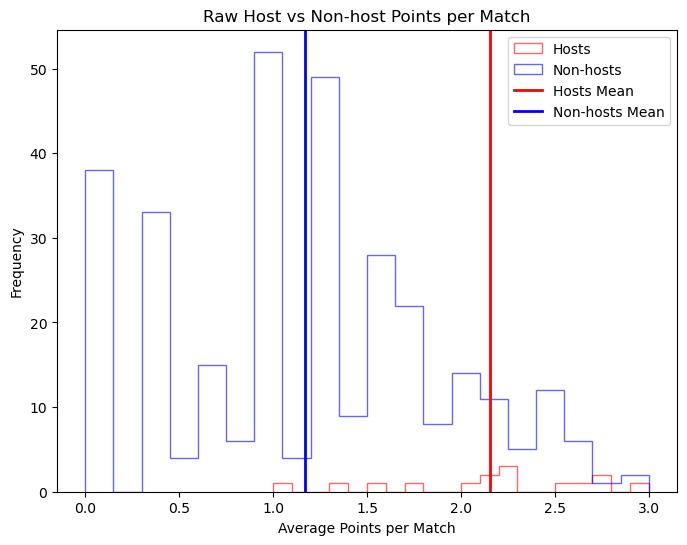

<Figure size 640x480 with 0 Axes>

In [391]:
plot_a (epah_hosts, epah_non_hosts, apm_hosts, apm_non_hosts)

The above histogram helps us view the distribution of each participating team’s average points per match in each World Cup. Points here are calculated using the ‘three points for a win’ standard where 3 points are awarded to a team for a win, 1 point for a draw, and 0 for a loss.
<br>
<br>
The distribution suggests that host nations tend to achieve a higher average points per match value than non-host nations. The mean difference appears to be almost 1 point per match.
<br>
<br>
However, one must consider that deciding to host the World Cup is partially self-selecting. Host nations tend to be countries that afford the financial costs associated with hosting, which include building new stadiums, having sufficient infrastructure to host hordes of tourists and having developed public services to ensure health and safety practices can be upheld. This all costs a lot. Countries that have the ability to fund this very often also have the ability to devote significant funding to national sporting teams too if sporting presence is a priority. Therefore, stronger World Cup performances by host nations may not be attributed entirely to hosting itself. International team strength should be considered alongside hosting.
<br>
<br>
International team strength has been quantified here by using each country’s Elo rating. Unlike FIFA rankings which were started in 1992, Football Elo ratings take into account all official international matches since 1872, giving a consistent measurement since the first world cup in 1930.
<br>
<br>
By comparing the Elo rating of a country, the year before the World Cup, to avoid using World Cup matches as part of our Elo ‘predictive’ data, and the eventual ranking in the world cup we can observe whether these two factors are correlated in any way.


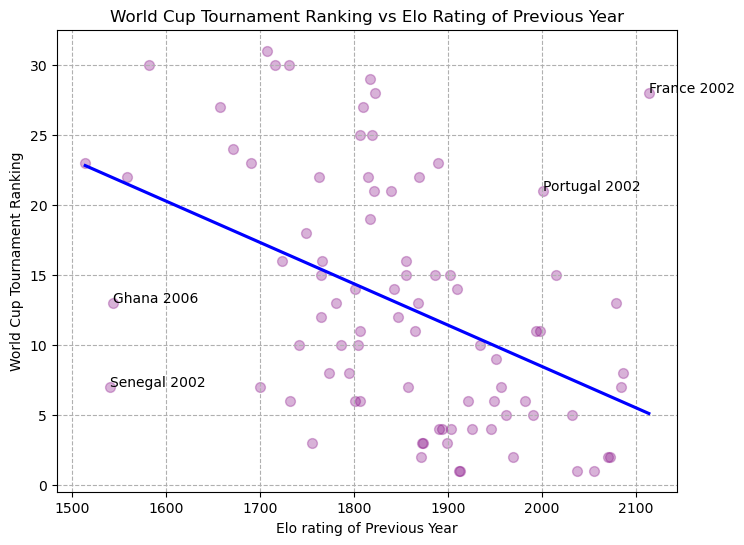

<Figure size 640x480 with 0 Axes>

In [392]:
plot_b (elo_and_performance)

Plotting this we observe a negative relationship – as a team’s Elo rating increases their ranking decreases (i.e. gets closer to 1st place). We can also view some significant, but interesting ouliers. This includes France at the 2002 World Cup, who entered as 1998 defending champions before placing last in Group A and scoring no goals. In comparison, Senegal at the 2002 World Cup, placed in group A with France, surpised everyone in their first World Cup appearance by progressing all the way to the quarter finals against Turkiye, where they were knocked out by a ‘golden goal’, a sudden death in extra time.
<br>
<br>
However, ranking is not necessarily the best measure to use to measure team performance, since the number of teams in a world cup has increased from 13 in 1930 to 32 in more modern matches. It has become increasingly competitive to rank First. Average points per match becomes a more reproducible way to measure team performance in the World Cup since it’s value takes into account the number of other participant teams.
<br>
<br>
Plotting this we observe a positive relationship – as a team’s Elo rating increases their average points per match increases (i.e. they perform better each game on average). In this graph, we can also clearly observe the stark difference between France’s performance in the 1998 and 2002 World Cups, where the average points per match for France decreased from just over 2.7 to under 0.4. Interestingly, France hosted the 1998 World Cup.


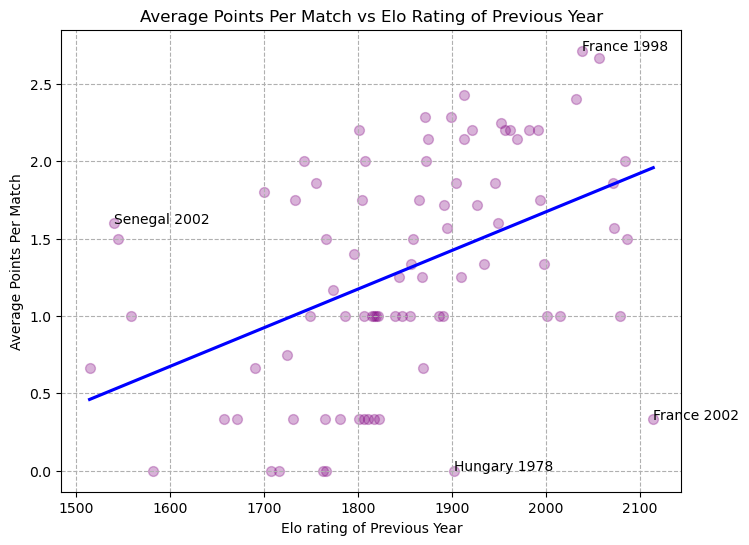

<Figure size 640x480 with 0 Axes>

In [393]:
plot_c (elo_and_performance1)

So, moving onwards, does this mean we can use Elo rating as reliable and reproducibile predictor of World Cup performance, where World Cup performance is expressed as average points per match?
<br>
<br>
To determine this, we can run a regression of our current model:
<br>
<br>
average_points_per_match = $α$ + $β$(elo_rating) + $e$
<br>
<br>
From this we obtain:


In [394]:
table_a (elo_and_performance1)

                            OLS Regression Results                            
Dep. Variable:       points_per_match   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     20.65
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.88e-05
Time:                        12:36:17   Log-Likelihood:                -83.245
No. Observations:                  84   AIC:                             170.5
Df Residuals:                      82   BIC:                             175.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3187      1.019     -3.256      0.0

There are a few values to pay attention to here. To start, Prob (F-statistic) = 0.0000188. This basically means that Elo rating is statistically significant in predicting average points per match at the 1% (0.01), and therefore also at the 5% (0.05), significance levels. The coefficient of rating is 0.0025. that means for every increase in the Elo rating by 1, the average points per match will typically increase by 0.0025. This means that a 400 point increase in Elo rating is typically associated with a 1 point increase in points per match. R-squared has a value of 0.201. This indicates that Elo ratings explain roughly 20.1% of the variation in average points per match. This also means that roughly 80% of variation in average points per match is unexplained in our current model. Overall, Elo is a statistically significant but partial predictor of points per match, so we should look to investigating other variables to explain the rest of the variance in points per match.
<br>
<br>
To investigate variance from the line of best fit, I created a residual term, where ‘residual’ equals the distance between each value and the predicted points per match based off of Elo rating. This redsidual value can be positive if the real value is higher than the predicted value or negative if lower than the predicted value. This quantifies all that is “unexplained” in our current model.
<br>
<br>
By plotting the residuals of hosts and non hosts separately as a box plot, we can observe how the residuals of hosts tends to be more positive than the residuals of non-hosts. Further, the residuals of hosts tend to have more variance than the residuals of non-hosts. This suggests since the model may be suffering from omitted variable bias correlated to hosting since residuals for hosting tend to be underpredicted at a wide variance, compared to non-hosters whoes performance looks to be predicted in a narrower, more accurate range.


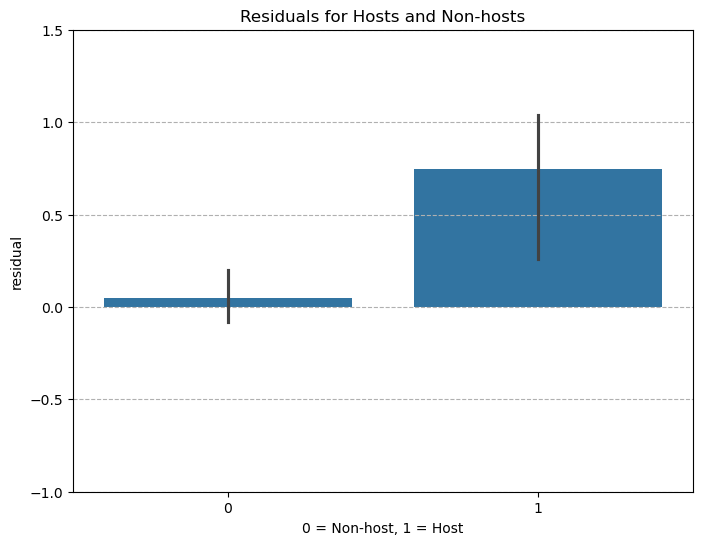

<Figure size 640x480 with 0 Axes>

In [395]:
plot_d (epah1)

To further investigate it, I created a dummy variable ‘is_host’ which has 2 values. When is_host is equivalent to 0 we are dealing with a non-host and when is_host is equivalent to 1 it indicates that the data refers to a hosting country. This then allowed me to then quantitatively test, through a t-test, whether the average residual between hosts (is_host = 1) and non-hosts (is_host = 0) is actually statistically different (rather than just looking like it).
<br>
<br>
The t-test outputted the following results: 


In [396]:
table_b (epah1)

t-statistic: -2.7691964161614666
p-value: 0.04169529990445051


Here, we should pay most attention to the p-value. A p-value of 0.020 (rounded up) means we can reject a null hypothesis that hosts and non-hosts have equal mean residuals at the 5% (0.05) significance level since 0.020 < 0.05. This p-value basically means that if there were no real difference between hosts and non-hosts, we would only expect to see differences between residuals this extreme roughly 2% of the time.
<br>
<br>
Next, I believed it was important to confirm whether the residual remained constant over all levels of Elo rating, our independent variable. If residuals, known as error terms, do remain constant this is known as ‘homoskedasticity’. If not, this is referred to as ‘heteroskedasticity’. It is important to confirm heteroskedasticity since if a model is heteroskedastic, p-values are often considered unreliable since t-tests will often overestimate the significance of results.
<br>
<br>
Plotting a scatter graph of Elo rating of the previous year against our residual can help us visualise whether our current model exhibits homoskedasticity:

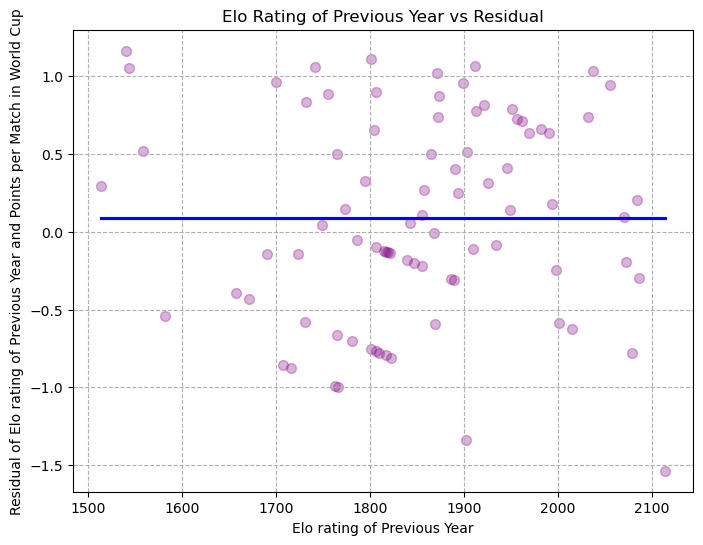

<Figure size 640x480 with 0 Axes>

In [397]:
plot_e (epah1)

Here, the vertical spread appears relatively constant over the range of Elo ratings, except two extreme outliers in the bottom right. While the spread does slightly widen at the upper end of Elo rating, it is not drastic enough to suggest strong evidence of heteroskedasticity.
<br>
<br>
Although homoskedasticity cannot be confirmed from this graph alone, as running statistical tests would be required, this scatter plot of residuals does not present a picture of heteroskedasticity. Considering the visual evidence available from the scatter plot, the residuals will be assumed to be homoskedastic for the remainder of the blog.
<br>
<br>
Next, I created a new regression model that considered the new variable is_host:
<br>
<br>
average_points_per_match = $α$ + $β$(elo_rating) + $γ$(is_host) + $e$
<br>
<br>
Running a regression of the independent variables elo_rating and is_host on average_points_per_match, the following table was obtained:

In [398]:
table_c (epah1)

                            OLS Regression Results                            
Dep. Variable:       points_per_match   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     13.69
Date:                Fri, 08 May 2026   Prob (F-statistic):           7.57e-06
Time:                        12:36:17   Log-Likelihood:                -80.453
No. Observations:                  84   AIC:                             166.9
Df Residuals:                      81   BIC:                             174.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3051      0.992     -3.331      0.0

We should pay attention to the is_host value p-value under P $> |$t$|$, which is 0.021. This is very similar to the independent t-test that was run on is_host earlier which resulted in a p-value of 0.020. This means that hosting remains a statistically significant predictor of points per match (at the 5% significance level) even after controlling for Elo rating.
<br>
<br>
It is also important to notice that the coefficient (under coef) is for is_host is 0.6989. We discussed earlier how the coefficient of rating (being 0.0025) indicates that for every 1 point increase in Elo_rating, there will typically be a 0.0025 point increase in points_per_match in the model. Here, the coefficient of is_host indicates that a change from 0 to 1 (going from a non-host to a host) is equivalent to a 0.70 (rounded up) increase in points_per_match.
<br>
<br>
This suggests that, in this model, the estimated effect of becoming a host country is similar in magnitude to the estimated effect associated with a 280 point increase in Elo rating. This is roughly equivalent to the difference between Algeria’s and England’s Elo rating (1743 vs 2020, a difference of 277) as of 2026.
<br>
<br>
Re-plotting again the scatter graph of Elo rating against average points per match, the difference in performance between hosts and non-hosts can be observed by plotting two different lines of best fit:

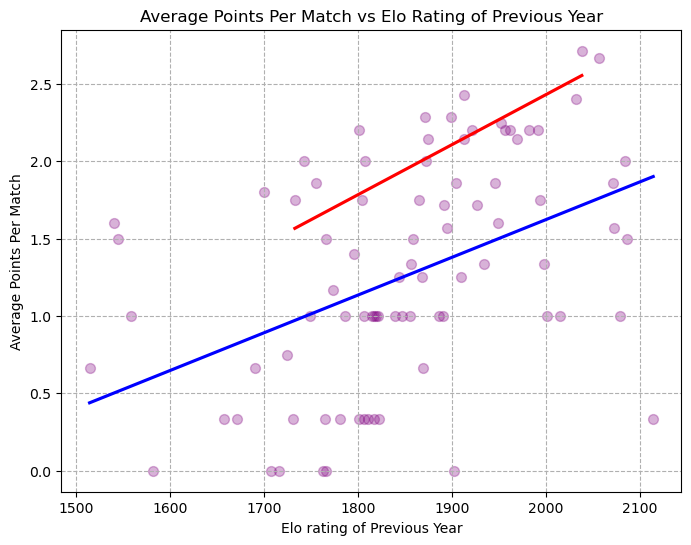

<Figure size 640x480 with 0 Axes>

In [399]:
plot_f (epah2)

It is clear from the lines of best fit that hosts tend to have a higher average points per match at the same Elo rating as non-hosts. The host’s line is roughly 0.7 points above the non-host line, as expected from our regression.
<br>
<br>
Finally, I added an interaction effect to see if the effect of Elo rating differs depending on whether a country is a World Cup host. This modifies the regression model to:
<br>
<br>
average_points_per_match = $α$ + $β$(elo_rating) + $γ$(is_host) + $δ$(elo_rating $*$ is_host) + $e$
<br>
<br>
Where elo_rating $*$ is_host is the interaction effect.
<br>
<br>
Running a regression on this, the following table is obtained:

In [400]:
table_d (epah2)

                            OLS Regression Results                            
Dep. Variable:       points_per_match   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     9.046
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.16e-05
Time:                        12:36:17   Log-Likelihood:                -80.412
No. Observations:                  84   AIC:                             168.8
Df Residuals:                      80   BIC:                             178.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.2509      1.017     -3.198      

It can be observed that the interaction effect does in fact not improve model performance. With the addition of an interaction variable, neither is_host or interaction are statistically significant at the 5% significance level (0.05) since both of their ‘P $> |$t$|$’ values are above 0.05. The interaction effect has likely introduced multicollinearity and is likely highly correlated with is_host.
<br>
<br>
Overall, using the following model:
<br>
<br>
average_points_per_match = $α$ + $β$(elo_rating) + $γ$(is_host) + $e$
<br>
<br>
We can suggest that being the host nation is associated a statistically significant advantage of roughly 0.70 extra points per match. It can also be suggested, in this model, that the estimated effect of becoming a host country is similar in magnitude to the estimated effect associated with a 280 point increase in Elo rating. 
<br>
<br>
However, I would be interested in investigating more variables, to potentially reduce the possibility the model is suffering from omitted variable bias. For example, I would look to examine squad market value, average opponent Elo, and confederation status (e.g. CONMEBOL is typically considered the most difficult to qualify in). I could also examine some factors linked to home advantage. For example, climate similarity (e.g. groups from warmer countries may perform better in heat than groups from cooler countries) and average elevation of country (e.g. Bolivia has a significant advantage at home that it loses in many countries due to their experience playing in elevation. This may overpredict their rank in Elo rating when playing abroad).
<br>
<br>
Further, since the dataset web scraped misses some recent World Cup data due to limitations, I would be interested in investigating these too to further add to this model. It will also be exciting to add the upcoming 2026 World Cup to the model and perhaps use this model to create some predictions for it.